In [1]:
%run parse_data.ipynb

In [2]:
from IPython.display import display,Markdown #,HTML
import numpy as np
from scipy import stats
from IPython.display import display,Markdown #,HTML
from matplotlib import pyplot as plt
import pandas as pd
import pingouin as pg

In [3]:
def display_title(s, pref='Figure', num=1, center=False):
    ctag = 'center' if center else 'p'
    s    = f'<{ctag}><span style="font-size: 1.2em;"><b>{pref} {num}</b>: {s}</span></{ctag}>'
    if pref=='Figure':
        s = f'{s}<br><br>'
    else:
        s = f'<br><br>{s}'
    display( Markdown(s) )

From the Variance Explained score of our descriptive PCA, we can see that Promotion have the highest ratio. The ratio shows that Promotion is highly varied across the dataset.

High variation usually calls for customer segmentation in business. We will intend use One-way ANOVA to test the hypothesis if segmentation in Promotion will increase the score of IBB, which in turn leads to higher BNPL usage rate 

First, we will divide the dataset into 3 groups: low, medium and high promotion score

In [4]:
# Using pd.cut to decide the width of the interval
promotion = df[['P', 'IBB']]

pd.cut(promotion.values.ravel(), 3)

[(2.333, 3.667], (2.333, 3.667], (2.333, 3.667], (0.996, 2.333], (2.333, 3.667], ..., (0.996, 2.333], (3.667, 5.0], (0.996, 2.333], (0.996, 2.333], (2.333, 3.667]]
Length: 1606
Categories (3, interval[float64, right]): [(0.996, 2.333] < (2.333, 3.667] < (3.667, 5.0]]

In [5]:
# Divide into groups
low_promotion = promotion.loc[promotion['P'] <= 2.333]
med_promotion = promotion.loc[(2.333 < promotion['P']) & (promotion['P'] <= 3.667)]
high_promotion = promotion.loc[promotion['P'] > 3.667]

Since the number of events in each interval is unequal, with over 1/2 of respondents falls into low promotion category, we will use Levene's test to know if 3 groups have homogeneous variance to be eligible for One-way ANOVA test

In [6]:
stats.levene(low_promotion['IBB'], med_promotion['IBB'], high_promotion['IBB'])

LeveneResult(statistic=4.779478575762907, pvalue=0.008641753676887572)

p value = 0.008 < 0.05 

We reject H0 and there is inhomogeneous variance between 3 groups. In this case, we will switch to Welch's ANOVA test for the groups.

In [7]:
bin = {1: 'Low', 2: 'Medium', 3: 'High'}

def p_segment(v):
    if v <= 2.333:
        return bin[1] 
    elif 2.333 < v <= 3.667:
        return bin[2] 
    else:
        return bin[3]

df['P_Segment'] = df['P'].apply(p_segment)


pg.welch_anova(data = df, dv = 'IBB', between = 'P_Segment')

,Source,ddof1,ddof2,F,p-unc,np2
0,P_Segment,2,353.225157,50.775318,4.145020e-20,0.104696


From the results, extreme values of F and p value reflects the nature of the data collected

p value  $\alpha$ < 0.05 -> We reject the H0 hypothesis, that is the mean score for IBB is the same throughout all categories. The test indicates our hypothesis if segmentation in Promotion will increase the IBB score is correct.

Further test to confirm where the main difference comes from includes Games-Howell Post Hoc tests

In [8]:
def difference_table(num = 1):
    display_title('Games-Howell Post Hoc Results for segmented Promotion respondents', pref='Table', num=num, center=False)
    a = pg.pairwise_gameshowell(data = df, dv = 'IBB', between = 'P_Segment')
    return a

difference_table(num = 1)

<br><br><p><span style="font-size: 1.2em;"><b>Table 1</b>: Games-Howell Post Hoc Results for segmented Promotion respondents</span></p>

,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,High,Low,3.263333,2.531926,0.731407,0.073989,9.885331,281.904196,9.547918e-15,0.872801
1,High,Medium,3.263333,2.882199,0.381134,0.085889,4.437507,329.184055,3.692048e-05,0.478978
2,Low,Medium,2.531926,2.882199,-0.350273,0.071429,-4.903801,371.285417,4.204617e-06,-0.412723


We can see that the main difference comes from the High and Low Promotion respondents, which is totally expected. However, the second highest difference comes from the High and Medium respondents; this information is crucial to BNPL services in further segmenting their customer base or potential customers. 

---

The correlation graph between independent variables and IBB shows that Social Influence has the highest correlation, yet in statistics, high correlation does not always equal to high causation. 

We will use hypothesis testing to test if an increase in Social Influence score will cause an increase in IBB score. The test we use will be simple linear regression

In [9]:
y = df['IBB']
P = df['P']
SC = df['SC']
SI = df['SI']
NE = df['NE']
H = df['H']
G = df['Gender']
S = df['Status']
I = df['Income']

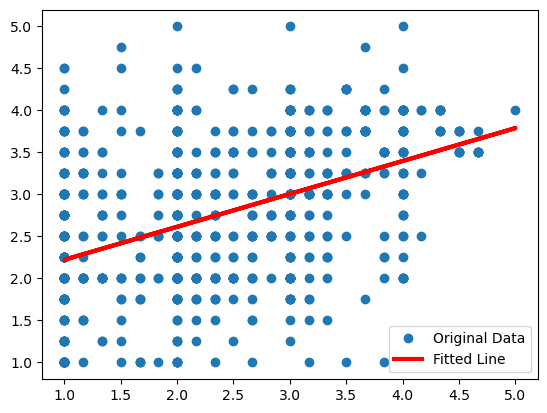

<p><span style="font-size: 1.2em;"><b>Figure 1</b>: Regression between Social Influence and IBB</span></p><br><br>

In [10]:
b = stats.linregress(df['SI'], df['IBB'])
values = [b.rvalue, b.pvalue]

def regression(num = 4):
    plt.plot(df['SI'], df['IBB'], 'o', label = 'Original Data')
    plt.plot(df['SI'], b.intercept + b.slope*df['SI'], 'r', label = 'Fitted Line', linewidth = 3)
    plt.legend()
    plt.show()
    
    display_title('Regression between Social Influence and IBB', pref='Figure', num=num, center=False)

regression(num = 1)

In [11]:
def regvalue_table(num = 2):        
    regvalue = pd.DataFrame()
    regvalue['R-value'] = [b.rvalue]
    regvalue['P-value'] = [b.pvalue]
    display_title('Regression between Social Influence and Impulsive Buying Behavior: R-value and P-value', pref='Table', num=num, center=False)

    return regvalue

regvalue_table(num = 2)

<br><br><p><span style="font-size: 1.2em;"><b>Table 2</b>: Regression between Social Influence and Impulsive Buying Behavior: R-value and P-value</span></p>

,R-value,P-value
0,0.441434,1.269096e-39


P-value $\alpha$ < 0.05, so we reject H0. Social Influence is statistically significant and we can imply causation effects of Social Influence on Impulsive Buying Behavior.

Based on the box plot, the distribution of Social Influence score is highly right-skewed. BNPL services providers have a large room left to increase the score and attract more customers.

---

There have been multiple studies in the past shows that people tend to overestimate their ability to control impulse [(Nordgren, 2007)](https://homepages.se.edu/cvonbergen/files/2013/01/The-Restraint-Bias_How-the-Illusion-of-Self-Restraint-Promotes-Impulsive-Behavior.pdf). This topic is highly relevent to BNPL providers since BNPL services usually thrives when people are highly impulsive. However, providers also need to balance the impulse of their customers to avoid customer burnout and negative impression from non-users. 

We will use two-sample t test to test the hypothesis if respondents with low self-control score overestimate their impulse control more than respondents with high self-control score. 

In [12]:
# define the bin value for low self-control and high self-control respondents
self_control = df[['SC', 'NE']]

pd.cut(promotion.values.ravel(), 2)

[(0.996, 3.0], (0.996, 3.0], (3.0, 5.0], (0.996, 3.0], (0.996, 3.0], ..., (0.996, 3.0], (3.0, 5.0], (0.996, 3.0], (0.996, 3.0], (0.996, 3.0]]
Length: 1606
Categories (2, interval[float64, right]): [(0.996, 3.0] < (3.0, 5.0]]

In [13]:
# divide into groups
low_sc = self_control.loc[self_control['SC'] <= 3]
high_sc = self_control.loc[(3 < self_control['SC']) & (self_control['SC'] <= 5)]

We once again use Levene's test to test for homogenity in variance between the 2 groups

In [14]:
print(stats.levene(low_sc['NE'], high_sc['NE']))

LeveneResult(statistic=6.607339766163802, pvalue=0.010335514646528009)


P-value  $\alpha$ < 0.05, so we reject H0. There is inhomogenity in variance between the groups. 

We will use a variation of standard t-test which is Welch's t-test to test our hypothesis in this case.

In [15]:
NE_ttest = stats.ttest_ind(high_sc['NE'], low_sc['NE'], equal_var = False)

def NE_result(num = 3):
    NE_visual = pd.DataFrame()
    NE_visual['t-statistic'] = [NE_ttest.statistic]
    NE_visual['p-value'] = [NE_ttest.pvalue]
    display_title("Welch's t-test result for Normative Evaluation between high and low Self-Control groups: T-statistics and P-value", pref='Table', num=num, center=False)

    return NE_visual

NE_result(num = 3)

<br><br><p><span style="font-size: 1.2em;"><b>Table 3</b>: Welch's t-test result for Normative Evaluation between high and low Self-Control groups: T-statistics and P-value</span></p>

,t-statistic,p-value
0,2.46369,0.014076


P-value  $\alpha$ < 0.05, so we reject H0. The difference between the mean for Normative Evaluation score between both groups is statistically significant.

t-statistic value shows the direction of the difference. t-statistic = 2.464 > 0, so we can conclude that the Normative Evaluation mean score in high Self-Control groups is higher than that in low Self-Control groups.

This rejects the hypothesis of low self-control score overestimate their impulse control more than respondents with high self-control score among the respondents.